In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# display all dataframe columns in df.head()
pd.options.display.max_columns = None
# display long string in datafame
pd.options.display.max_colwidth = 300

# filter out warning messages
import warnings

warnings.filterwarnings("ignore")

In [2]:
data_dict = pd.read_csv("data/data_dictionary.csv")
data_dict

,ColumnName,Description
0,acc_now_delinq,The number of accounts on which the borrower is now delinquent.
1,addr_state,The state provided by the borrower in the loan application
2,annual_inc,The self-reported annual income provided by the borrower during registration.
3,application_type,Indicates whether the loan is an individual application or a joint application with two co-borrowers
4,chargeoff_within_12_mths,Number of charge-offs within 12 months
5,collection_recovery_fee,post charge off collection fee
6,collections_12_mths_ex_med,Number of collections in 12 months excluding medical collections
7,debt_settlement_flag,"Flags whether or not the borrower, who has charged-off, is working with a debt-settlement company."
8,debt_settlement_flag_date,The most recent date that the Debt_Settlement_Flag has been set
9,delinq_2yrs,The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years


In [3]:
loan_df = pd.read_csv("data/lending_club_2007_2011_6_states.csv")
loan_df.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date
5718,6000,6000,6000.000000,36 months,10.99,196.41,B,B3,Los Angeles Times,3 years,RENT,52000.0,Verified,Jul-2011,Fully Paid,n,moving,Lending Club,900xx,CA,12.09,1.0,Jan-2002,0.0,20.0,NaN,6.0,0.0,2769,71.2,10.0,f,0.0,0.0,6586.381235,6586.38,6000.0,571.38,15.0,0.0,0.0,Aug-2012,4420.08,NaN,Oct-2016,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
3956,10000,10000,10000.000000,36 months,5.99,304.18,A,A2,"St. Luke's Lutheran Church, Logan Square",5 years,MORTGAGE,62000.0,Not Verified,Sep-2011,Fully Paid,n,debt_consolidation,Consolidation Loan #2,606xx,IL,12.93,0.0,May-1993,0.0,NaN,NaN,15.0,0.0,11118,33.7,57.0,f,0.0,0.0,10927.739538,10927.74,10000.0,927.74,0.0,0.0,0.0,Apr-2014,1803.38,NaN,Jan-2019,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
17876,15000,15000,14450.000000,36 months,12.18,499.50,B,B4,Wells Fargo Bank,10+ years,MORTGAGE,78408.0,Verified,Aug-2009,Fully Paid,n,debt_consolidation,Consolidate Credit Card Debt,922xx,CA,18.26,0.0,Jul-1989,3.0,NaN,NaN,8.0,0.0,32207,61.7,32.0,f,0.0,0.0,15990.633639,15404.31,15000.0,990.63,0.0,0.0,0.0,May-2010,7.17,NaN,Jun-2011,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
12048,10000,10000,9995.520851,36 months,5.79,303.27,A,A2,Northwest Community Hospital,3 years,OWN,50000.0,Not Verified,Oct-2010,Fully Paid,n,credit_card,CC Loan Payoff,607xx,IL,16.22,0.0,Oct-2000,0.0,NaN,NaN,7.0,0.0,9669,27.2,22.0,f,0.0,0.0,10917.859309,10912.61,10000.0,917.86,0.0,0.0,0.0,Nov-2013,328.84,NaN,Nov-2013,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
14807,12000,12000,11975.000000,36 months,15.70,420.11,D,D4,"RTC Group, Inc.",5 years,MORTGAGE,64800.0,Not Verified,May-2010,Fully Paid,n,credit_card,Paying Off Last Credit Cards,328xx,FL,19.44,0.0,Dec-1999,0.0,NaN,NaN,8.0,0.0,40123,87.4,20.0,f,0.0,0.0,14510.514336,14480.28,12000.0,2510.52,0.0,0.0,0.0,Mar-2012,6120.88,NaN,Nov-2018,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN


In [4]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19908 entries, 0 to 19907
Data columns (total 58 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_amnt                    19908 non-null  int64  
 1   funded_amnt                  19908 non-null  int64  
 2   funded_amnt_inv              19908 non-null  float64
 3   term                         19908 non-null  object 
 4   int_rate                     19908 non-null  float64
 5   installment                  19908 non-null  float64
 6   grade                        19908 non-null  object 
 7   sub_grade                    19908 non-null  object 
 8   emp_title                    18723 non-null  object 
 9   emp_length                   19409 non-null  object 
 10  home_ownership               19908 non-null  object 
 11  annual_inc                   19908 non-null  float64
 12  verification_status          19908 non-null  object 
 13  issue_d         

In [5]:
loan_df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,next_pymnt_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
count,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,1.990800e+04,19908.000000,19908.000000,19908.000000,6998.000000,1209.000000,19908.000000,19908.000000,19908.000000,19889.000000,19908.000000,19908.0,19908.0,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,0.0,19893.0,0.0,19908.0,19908.0,19893.0,19908.0,19595.000000,19898.0
mean,11353.846444,11065.763763,10500.929748,12.089717,330.614254,7.107345e+04,13.008619,0.143962,0.829466,35.841097,69.354839,9.278782,0.046715,13363.994826,49.424966,21.527627,0.0,0.0,12286.852391,11690.155107,9913.519990,2277.120129,1.489973,94.722382,11.861625,2636.253711,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.037969,0.0
std,7463.700492,7176.276661,7106.229650,3.698287,210.557434,6.980565e+04,6.663658,0.489576,1.044978,21.599170,44.520279,4.414903,0.217827,15943.303849,28.198395,11.269006,0.0,0.0,9098.847567,8984.722396,7126.424699,2583.733214,7.964257,666.434583,141.910324,4412.964304,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.191393,0.0
min,500.000000,500.000000,0.000000,5.420000,15.690000,4.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.000000,0.0
25%,5750.000000,5600.000000,5000.000000,9.450000,171.287500,4.200000e+04,7.840000,0.000000,0.000000,19.000000,0.000000,6.000000,0.000000,3770.500000,26.500000,13.000000,0.0,0.0,5670.592545,5239.857500,4800.000000,687.595000,0.000000,0.000000,0.000000,222.530000,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.000000,0.0
50%,10000.000000,10000.000000,9000.000000,11.860000,285.780000,6.000000e+04,13.075000,0.000000,0.000000,34.000000,90.000000,9.000000,0.000000,8876.500000,50.300000,20.000000,0.0,0.0,10042.735817,9427.845000,8000.000000,1389.230000,0.000000,0.000000,0.000000,544.700000,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.000000,0.0
75%,15000.000000,15000.000000,14500.000000,14.610000,440.815000,8.500000e+04,18.200000,0.000000,1.000000,51.000000,104.000000,12.000000,0.000000,16952.250000,72.800000,28.000000,0.0,0.0,16681.688450,15983.440000,14000.000000,2842.795000,0.000000,0.000000,0.000000,3193.352500,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.000000,0.0
max,35000.000000,35000.000000,35000.000000,24.400000,1302.690000,6.000000e+06,29.990000,11.000000,8.000000,106.000000,129.000000,44.000000,3.000000,148829.000000,99.900000,90.000000,0.0,0.0,58480.139915,58438.370000,35000.020000,23480.140000,180.200000,29623.350000,6543.040000,35596.410000,NaN,0.0,NaN,1.0,0.0,0.0,0.0,2.000000,0.0


### Paid-Off Rate and Annual Return

#### Paid-off rates


In [6]:
loan_df.loan_status.value_counts()

loan_status
Fully Paid     16965
Charged Off     2943
Name: count, dtype: int64

In [7]:
mapping_dict = {"Charged Off": 0, "Fully Paid": 1}
loan_df["repaid"] = loan_df.loan_status.map(mapping_dict)
loan_df.repaid.value_counts()

repaid
1    16965
0     2943
Name: count, dtype: int64

In [8]:
loan_df.repaid.mean()

np.float64(0.8521699819168174)

#### Annual return


In [9]:
loan_df.term.value_counts()

term
36 months    14852
60 months     5056
Name: count, dtype: int64

In [10]:
loan_df["total_return"] = (
    loan_df.total_pymnt + loan_df.recoveries
) / loan_df.funded_amnt - 1

loan_df["loan_term_year"] = loan_df.term.apply(lambda x: 3 if x == "36 months" else 5)

loan_df["annual_return"] = loan_df.apply(
    lambda x: (1 + x.total_return) ** (1 / x.loan_term_year) - 1, axis=1
)

loan_df.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,repaid,total_return,loan_term_year,annual_return
16088,16000,16000,15975.0,36 months,16.45,566.04,E,E1,DaVita Dialysis,3 years,MORTGAGE,78000.0,Not Verified,Feb-2010,Fully Paid,n,debt_consolidation,Debt Consolidation,937xx,CA,14.74,0.0,Aug-2002,3.0,32.0,NaN,7.0,0.0,3745,89.2,18.0,f,0.0,0.0,20385.634274,20353.78,16000.00,4385.63,0.00000,0.00,0.0000,Mar-2013,606.66,NaN,Feb-2019,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN,1,0.274102,3,0.084097
13973,14400,11250,11050.0,60 months,10.75,243.21,B,B2,Flagler County Fire Rescue,5 years,MORTGAGE,56000.0,Not Verified,Jul-2010,Charged Off,n,other,Other loan,321xx,FL,18.06,0.0,Dec-1996,0.0,NaN,NaN,7.0,0.0,2464,15.7,23.0,f,0.0,0.0,5250.180000,5156.84,2612.64,1087.31,44.89352,1505.34,330.1434,Aug-2011,245.00,NaN,Oct-2016,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN,0,-0.399509,5,-0.096972
8730,28000,28000,25650.0,60 months,14.91,664.80,D,D2,Lowe's Home Improvement Warehouse,10+ years,RENT,67100.0,Verified,Mar-2011,Fully Paid,n,debt_consolidation,Debt Consolidation,770xx,TX,17.56,0.0,Feb-1994,1.0,NaN,NaN,6.0,0.0,33683,70.6,19.0,f,0.0,0.0,36508.468493,33444.36,28000.00,8508.47,0.00000,0.00,0.0000,Oct-2013,17236.48,NaN,Apr-2015,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN,1,0.303874,5,0.054501
17048,7000,7000,6925.0,36 months,8.94,222.41,A,A5,Navfac southwest,10+ years,MORTGAGE,120000.0,Not Verified,Nov-2009,Fully Paid,n,other,advancecredit,921xx,CA,9.44,0.0,Nov-1998,0.0,60.0,NaN,9.0,0.0,7124,31.0,35.0,f,0.0,0.0,7463.237776,7383.27,7000.00,463.24,0.00000,0.00,0.0000,Oct-2010,5467.30,NaN,Oct-2010,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN,1,0.066177,3,0.021589
13624,14000,14000,13500.0,36 months,13.23,473.27,C,C1,NRT REOexperts,4 years,MORTGAGE,64000.0,Not Verified,Aug-2010,Fully Paid,n,debt_consolidation,credit payoff,334xx,FL,16.84,0.0,Jan-1999,1.0,NaN,NaN,6.0,0.0,14911,81.9,22.0,f,0.0,0.0,16453.831703,15866.21,14000.00,2453.83,0.00000,0.00,0.0000,Aug-2012,2087.40,NaN,Aug-2012,0.0,NaN,1,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN,1,0.175274,3,0.055309


#### Portfolio return


In [11]:
# Portfolio - all loans
loan_df.annual_return.mean()

np.float64(0.019144455246204173)

In [12]:
# Portfolio - all fully paid loans
loan_df[loan_df.repaid == 1].annual_return.mean()

np.float64(0.049728921833471745)

In [13]:
# Portfolio - all charged off loans
loan_df[loan_df.repaid == 0].annual_return.mean()

np.float64(-0.15716049740517005)

In [14]:
loan_df[loan_df.mths_since_last_record >= 0].repaid.mean()

np.float64(0.7849462365591398)

## Feature Selection


### Feature Exclusion


Exclude features that are only available after loan origination. Many of these selections come from domain knowledge, and the descriptions in the `data_dictionary.csv`, to determine whether the data would be available.


In [15]:
loan_df.drop(
    columns=[
        "collection_recovery_fee",
        "debt_settlement_flag",
        "debt_settlement_flag_date",
        "disbursement_method",
        "funded_amnt",
        "funded_amnt_inv",
        "initial_list_status",
        "installment",
        "issue_d",
        "last_credit_pull_d",
        "last_pymnt_amnt",
        "last_pymnt_d",
        "loan_status",
        "next_pymnt_d",
        "out_prncp",
        "out_prncp_inv",
        "pymnt_plan",
        "recoveries",
        "total_pymnt",
        "total_pymnt_inv",
        "total_rec_int",
        "total_rec_late_fee",
        "total_rec_prncp",
    ],
    inplace=True,
)


Exclude features that have too many missing values **and** the missing values are hard to fill.


In [16]:
loan_df.isnull().sum().sort_values(ascending=False)


mths_since_last_major_derog    19908
mths_since_last_record         18699
mths_since_last_delinq         12910
emp_title                       1185
emp_length                       499
pub_rec_bankruptcies             313
revol_util                        19
chargeoff_within_12_mths          15
collections_12_mths_ex_med        15
tax_liens                         10
title                              5
loan_amnt                          0
sub_grade                          0
term                               0
int_rate                           0
grade                              0
addr_state                         0
dti                                0
home_ownership                     0
purpose                            0
zip_code                           0
verification_status                0
annual_inc                         0
revol_bal                          0
pub_rec                            0
open_acc                           0
inq_last_6mths                     0
d

The column `mths_since_last_major_derog` does not contain any data available to fill in missing values.


In [17]:
loan_df.mths_since_last_major_derog.notna().sum()


np.int64(0)

The column `mths_since_last_record` has only about 6% of data available, and filling in missing values would result in less accurate data.


In [18]:
mths_since_last_record_not_null = loan_df.mths_since_last_record.notna().sum()
mths_since_last_record_is_null = loan_df.mths_since_last_record.isna().sum()

print("Total `mths_since_last_record` not null:", mths_since_last_record_not_null)
print("Total `mths_since_last_record` is null:", mths_since_last_record_is_null)

print(
    "Percentage of data available:",
    mths_since_last_record_not_null / mths_since_last_record_is_null,
)


Total `mths_since_last_record` not null: 1209
Total `mths_since_last_record` is null: 18699
Percentage of data available: 0.06465586394994385


The `mths_since_last_delinq` column has about 54% of data available. Most of the number of months are about 20-40, and the histogram plot is right skewed, in which the mean is greater than the median. Although the missing values could be filled in with the mean, doing so would lead to inaccurate data, impacting half of the data set and skewing the data heavily towards the mean.


Total `mths_since_last_delinq` not null: 6998
Total `mths_since_last_delinq` is null: 12910
Perentage of data available: 0.5420604182804027
Mean: 35.84109745641612
Median: 34.0


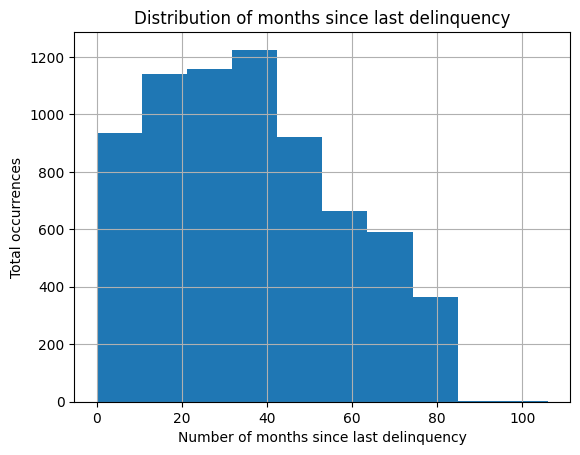

In [19]:
mths_since_last_delinq_not_null = loan_df.mths_since_last_delinq.notna().sum()
mths_since_last_delinq_is_null = loan_df.mths_since_last_delinq.isna().sum()

print("Total `mths_since_last_delinq` not null:", mths_since_last_delinq_not_null)
print("Total `mths_since_last_delinq` is null:", mths_since_last_delinq_is_null)

print(
    "Perentage of data available:",
    mths_since_last_delinq_not_null / mths_since_last_delinq_is_null,
)

loan_df.mths_since_last_delinq.hist().set(
    title="Distribution of months since last delinquency",
    xlabel="Number of months since last delinquency",
    ylabel="Total occurrences",
)

mths_since_last_delinq_mean = np.mean(loan_df.mths_since_last_delinq)

print("Mean:", mths_since_last_delinq_mean)

print(
    "Median:",
    np.median(loan_df[loan_df.mths_since_last_delinq.notnull()].mths_since_last_delinq),
)

# loan_df.mths_since_last_delinq.fillna(mths_since_last_delinq_mean, inplace=True)
# loan_df.mths_since_last_delinq.isnull().sum()


The `emp_title` has too many variants, where filling in missing values would be challenging.


In [20]:
emp_title_unique = loan_df.emp_title.unique()
emp_title_values = loan_df.emp_title.value_counts()

print("`emp_title` unique values:", emp_title_unique)
print("`emp_title` total values:", emp_title_values)


`emp_title` unique values: [nan 'AIR RESOURCES BOARD' 'MKC Accounting ' ... 'Ping Interactive'
 'UNIQUE ID WEB DESIGN' 'Institute for Mind/Body Research and Education']
`emp_title` total values: emp_title
Bank of America                       53
Kaiser Permanente                     50
State of California                   42
US Army                               40
AT&T                                  36
                                      ..
Northwestern Mutual Life Insurance     1
Suniland Associates, LTD.              1
NYCPD                                  1
Equality Florida                       1
Cuban Medical Association              1
Name: count, Length: 15047, dtype: int64


The `emp_length` column has only 499 missing values. Given that the most frequently occurring value is `10+ years`, this was the value used to fill in missing values.


`emp_length` unique values: ['10+ years' '9 years' '4 years' '< 1 year' '3 years' '6 years' '5 years'
 '1 year' '2 years' '7 years' '8 years' nan]
`emp_length` total values: emp_length
10+ years    4249
< 1 year     2306
2 years      2218
3 years      2108
4 years      1871
5 years      1649
1 year       1637
6 years      1151
7 years       867
8 years       718
9 years       635
Name: count, dtype: int64


[Text(0.5, 1.0, 'Distribution of employment length (missing values)'),
 Text(0.5, 0, 'Number of years'),
 Text(0, 0.5, 'Total occurrences')]

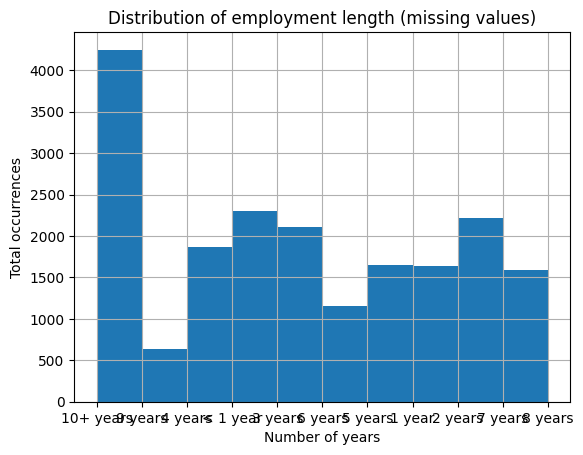

In [21]:
emp_length_unique = loan_df.emp_length.unique()
emp_length_values = loan_df.emp_length.value_counts()

print("`emp_length` unique values:", emp_length_unique)
print("`emp_length` total values:", emp_length_values)

loan_df.emp_length.hist().set(
    title="Distribution of employment length (missing values)",
    xlabel="Number of years",
    ylabel="Total occurrences",
)


[Text(0.5, 1.0, 'Distribution of employment length (no missing values)'),
 Text(0.5, 0, 'Number of years'),
 Text(0, 0.5, 'Total occurrences')]

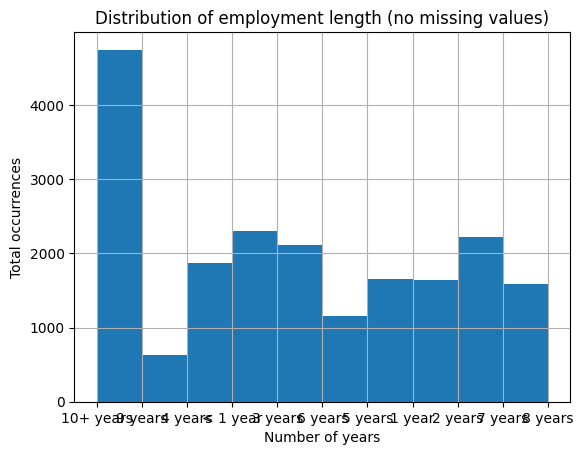

In [22]:
loan_df.emp_length.fillna(emp_length_unique[0], inplace=True)

loan_df.emp_length.hist().set(
    title="Distribution of employment length (no missing values)",
    xlabel="Number of years",
    ylabel="Total occurrences",
)


The columns `pub_rec_bankruptcies` and `revol_util` have 313 and 19 missing values, respectively. Given the fewer amounts of missing data, and their relevance in being available prior to loan origination, the missing data can be filled in.


`pub_rec_bankruptcies` unique values: [ 0.  1.  2. nan]
`pub_rec_bankruptcies` total values: pub_rec_bankruptcies
0.0    18852
1.0      742
2.0        1
Name: count, dtype: int64


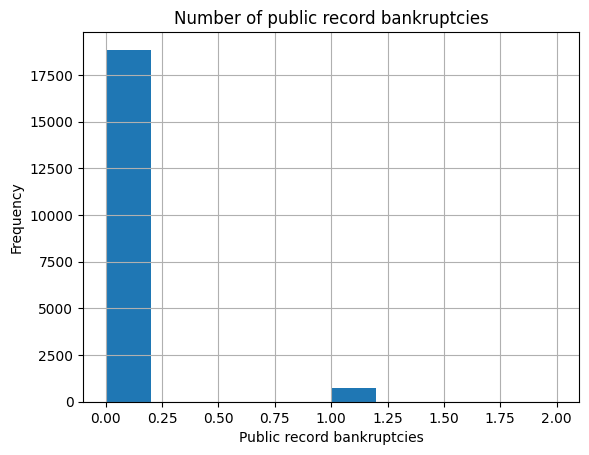

In [23]:
pub_rec_bankruptcies_unique = loan_df.pub_rec_bankruptcies.unique()
pub_rec_bankruptcies_values = loan_df.pub_rec_bankruptcies.value_counts()

print("`pub_rec_bankruptcies` unique values:", pub_rec_bankruptcies_unique)
print("`pub_rec_bankruptcies` total values:", pub_rec_bankruptcies_values)

loan_df.pub_rec_bankruptcies.hist().set(
    title="Number of public record bankruptcies",
    xlabel="Public record bankruptcies",
    ylabel="Frequency",
)

loan_df.pub_rec_bankruptcies.fillna(pub_rec_bankruptcies_unique[0], inplace=True)


In [24]:
loan_df.revol_util.fillna(np.mean(loan_df.revol_util), inplace=True)


In [25]:
loan_df.drop(
    columns=[
        "emp_title",
        "mths_since_last_delinq",
        "mths_since_last_major_derog",
        "mths_since_last_record",
    ],
    inplace=True,
)


Exclude categorical features that have too many categories.


In [26]:
# loan_df.apply(lambda x: x.unique())
# loan_df.value_counts()

loan_df.nunique().sort_values(ascending=False)


total_return                  19826
annual_return                 19820
revol_bal                     14028
title                         10538
annual_inc                     2996
dti                            2710
revol_util                     1053
loan_amnt                       727
earliest_cr_line                506
int_rate                        353
zip_code                        260
total_acc                        70
open_acc                         37
sub_grade                        35
purpose                          14
emp_length                       11
delinq_2yrs                      10
inq_last_6mths                    9
grade                             7
addr_state                        6
home_ownership                    5
pub_rec                           4
verification_status               3
pub_rec_bankruptcies              3
term                              2
repaid                            2
loan_term_year                    2
chargeoff_within_12_mths    

In [27]:
for col in loan_df:
    if len(loan_df[col].unique()) < 15:
        print(col, loan_df[col].unique())


term ['36 months' '60 months']
grade ['C' 'E' 'F' 'B' 'A' 'D' 'G']
emp_length ['10+ years' '9 years' '4 years' '< 1 year' '3 years' '6 years' '5 years'
 '1 year' '2 years' '7 years' '8 years']
home_ownership ['RENT' 'OWN' 'MORTGAGE' 'OTHER' 'NONE']
verification_status ['Not Verified' 'Source Verified' 'Verified']
purpose ['small_business' 'other' 'car' 'debt_consolidation' 'credit_card'
 'home_improvement' 'major_purchase' 'moving' 'medical' 'house' 'vacation'
 'wedding' 'renewable_energy' 'educational']
addr_state ['IL' 'CA' 'TX' 'FL' 'NY' 'NJ']
delinq_2yrs [ 0.  1.  2.  3.  4.  5.  6.  7. 11.  8.]
inq_last_6mths [2. 1. 0. 3. 4. 6. 7. 5. 8.]
pub_rec [0. 1. 2. 3.]
collections_12_mths_ex_med [ 0. nan]
policy_code [1]
application_type ['Individual']
acc_now_delinq [0.]
chargeoff_within_12_mths [ 0. nan]
delinq_amnt [0.]
pub_rec_bankruptcies [0. 1. 2.]
tax_liens [ 0. nan]
hardship_flag ['N']
repaid [1 0]
loan_term_year [3 5]


The columns `sub_grade`, `title`, and `zip_code` have too many unique values as categories. Each of these columns has a comparable equivalent column with fewer unique categories. The table below illustrates the columns and their comparable equivalent columns.

| Column      | Number of categories | Comparable column | Number of comparable categories |
| ----------- | -------------------- | ----------------- | ------------------------------- |
| `sub_grade` | 35                   | `grade`           | 7                               |
| `title`     | 10539                | `purpose`         | 14                              |
| `zip_code`  | 260                  | `addr_state`      | 6                               |


In [28]:
print("Total `sub_grade` categories:", len(loan_df.sub_grade.unique()))
print("Total `title` categories:", len(loan_df.title.unique()))
print("Total `zip_code` categories:", len(loan_df.zip_code.unique()))


Total `sub_grade` categories: 35
Total `title` categories: 10539
Total `zip_code` categories: 260


In [29]:
print("Total `addr_state` categories:", len(loan_df.addr_state.unique()))
print("Total `grade` categories:", len(loan_df.grade.unique()))
print("Total `purpose` categories:", len(loan_df.purpose.unique()))


Total `addr_state` categories: 6
Total `grade` categories: 7
Total `purpose` categories: 14


Regarding the `sub_grade` and `grade` columns, the following plots illustrate that having the additional sub-grade values does not significantly impact the paid-off rate or annual return. Although there are a few outliers with G2 and G4 sub-grade loans, these outliers can likely be ignored, since such outliers do not occur on all G grade loans.


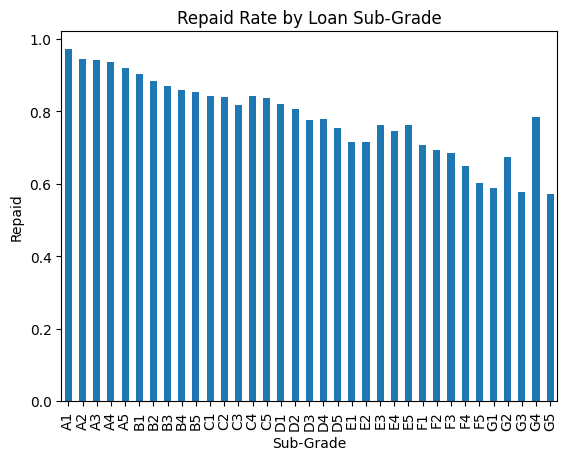

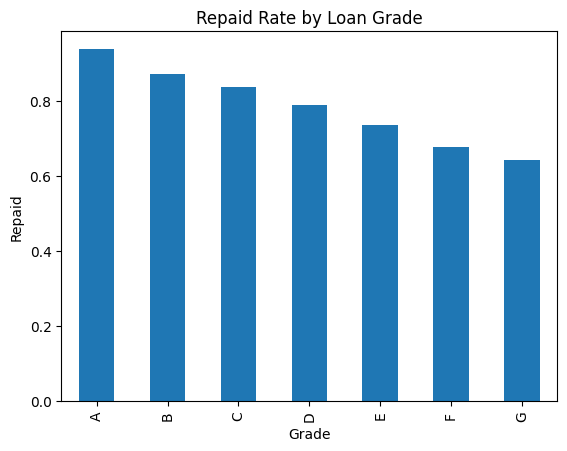

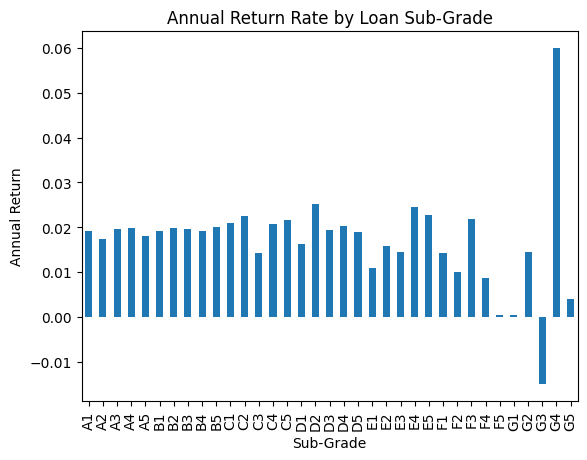

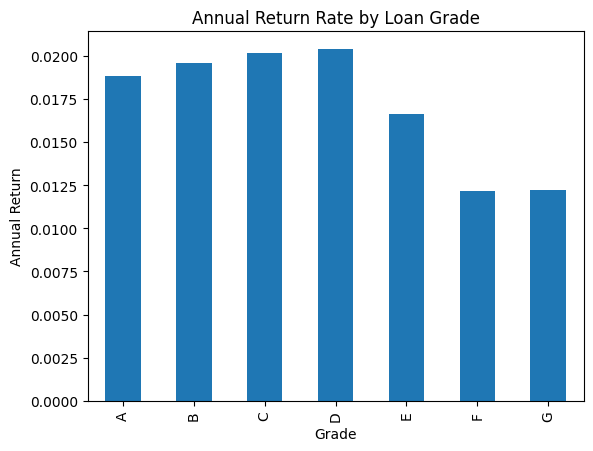

In [30]:
loan_df.groupby("sub_grade").agg("repaid").mean().plot.bar()
plt.title("Repaid Rate by Loan Sub-Grade")
plt.xlabel("Sub-Grade")
plt.ylabel("Repaid")
plt.show()

loan_df.groupby("grade").agg("repaid").mean().plot.bar()
plt.title("Repaid Rate by Loan Grade")
plt.xlabel("Grade")
plt.ylabel("Repaid")
plt.show()

loan_df.groupby("sub_grade").agg("annual_return").mean().plot.bar()
plt.title("Annual Return Rate by Loan Sub-Grade")
plt.xlabel("Sub-Grade")
plt.ylabel("Annual Return")
plt.show()

loan_df.groupby("grade").agg("annual_return").mean().plot.bar()
plt.title("Annual Return Rate by Loan Grade")
plt.xlabel("Grade")
plt.ylabel("Annual Return")
plt.show()


In [31]:
loan_df.drop(columns=["sub_grade", "title", "zip_code"], inplace=True)


Exclude features that have just one value.


In [32]:
loan_df.nunique().sort_values()


delinq_amnt                       1
tax_liens                         1
hardship_flag                     1
chargeoff_within_12_mths          1
policy_code                       1
application_type                  1
acc_now_delinq                    1
collections_12_mths_ex_med        1
term                              2
loan_term_year                    2
repaid                            2
verification_status               3
pub_rec_bankruptcies              3
pub_rec                           4
home_ownership                    5
addr_state                        6
grade                             7
inq_last_6mths                    9
delinq_2yrs                      10
emp_length                       11
purpose                          14
open_acc                         37
total_acc                        70
int_rate                        353
earliest_cr_line                506
loan_amnt                       727
revol_util                     1053
dti                         

In [33]:
loan_df.drop(
    columns=[
        "acc_now_delinq",
        "application_type",
        "chargeoff_within_12_mths",
        "collections_12_mths_ex_med",
        "delinq_amnt",
        "hardship_flag",
        "policy_code",
        "tax_liens",
    ],
    inplace=True,
)


Exclude `term` column, and use `loan_term_year` column instead.


In [34]:
loan_df.drop(columns="term", inplace=True)


Exclude `earliest_cr_line` column, and create `earliest_cr_line_year` column instead.


In [35]:
loan_df["earliest_cr_line_year"] = loan_df.earliest_cr_line.apply(
    lambda x: x.split("-")[1]
)
loan_df["earliest_cr_line_year"]

# Exclude `earliest_cr_line` column
loan_df.drop(columns="earliest_cr_line", inplace=True)


### Feature Inclusion


In [36]:
loan_df.info()
loan_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19908 entries, 0 to 19907
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   loan_amnt              19908 non-null  int64  
 1   int_rate               19908 non-null  float64
 2   grade                  19908 non-null  object 
 3   emp_length             19908 non-null  object 
 4   home_ownership         19908 non-null  object 
 5   annual_inc             19908 non-null  float64
 6   verification_status    19908 non-null  object 
 7   purpose                19908 non-null  object 
 8   addr_state             19908 non-null  object 
 9   dti                    19908 non-null  float64
 10  delinq_2yrs            19908 non-null  float64
 11  inq_last_6mths         19908 non-null  float64
 12  open_acc               19908 non-null  float64
 13  pub_rec                19908 non-null  float64
 14  revol_bal              19908 non-null  int64  
 15  re

,loan_amnt,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies,repaid,total_return,loan_term_year,annual_return
count,19908.000000,19908.000000,1.990800e+04,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.00000,19908.000000,19908.000000,19908.000000
mean,11353.846444,12.089717,7.107345e+04,13.008619,0.143962,0.829466,9.278782,0.046715,13363.994826,49.424966,21.527627,0.037372,0.85217,0.107970,3.507937,0.019144
std,7463.700492,3.698287,6.980565e+04,6.663658,0.489576,1.044978,4.414903,0.217827,15943.303849,28.184935,11.269006,0.189941,0.35494,0.267606,0.870581,0.100369
min,500.000000,5.420000,4.000000e+03,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.00000,-1.000000,3.000000,-1.000000
25%,5750.000000,9.450000,4.200000e+04,7.840000,0.000000,0.000000,6.000000,0.000000,3770.500000,26.500000,13.000000,0.000000,1.00000,0.085900,3.000000,0.026958
50%,10000.000000,11.860000,6.000000e+04,13.075000,0.000000,0.000000,9.000000,0.000000,8876.500000,50.200000,20.000000,0.000000,1.00000,0.155383,3.000000,0.045594
75%,15000.000000,14.610000,8.500000e+04,18.200000,0.000000,1.000000,12.000000,0.000000,16952.250000,72.800000,28.000000,0.000000,1.00000,0.224674,5.000000,0.062750
max,35000.000000,24.400000,6.000000e+06,29.990000,11.000000,8.000000,44.000000,3.000000,148829.000000,99.900000,90.000000,2.000000,1.00000,1.241516,5.000000,0.295472


#### Categorical Feature Selection


In [37]:
from sklearn.preprocessing import LabelEncoder

categorical_features = loan_df[
    [
        "addr_state",
        "emp_length",
        "grade",
        "home_ownership",
        "loan_term_year",
        "purpose",
        "verification_status",
    ]
]

categorical_features = categorical_features.apply(LabelEncoder().fit_transform)

categorical_features


,addr_state,emp_length,grade,home_ownership,loan_term_year,purpose,verification_status
0,2,1,2,4,0,11,0
1,0,1,2,4,0,9,1
2,0,9,4,4,0,0,1
3,0,4,5,3,1,11,1
4,5,10,1,4,1,9,2
...,...,...,...,...,...,...,...
19903,4,0,1,0,0,9,0
19904,1,10,1,4,0,3,0
19905,4,2,2,4,0,11,0
19906,4,2,2,0,0,4,0


#### Continuous Feature Selection


In [38]:
continuous_features = loan_df[
    [
        "annual_inc",
        "dti",
        "delinq_2yrs",
        "earliest_cr_line_year",
        "inq_last_6mths",
        "int_rate",
        "loan_amnt",
        "open_acc",
        "pub_rec",
        "pub_rec_bankruptcies",
        "revol_bal",
        "revol_util",
        "total_acc",
        "total_return",
    ]
]


#### Encode features and label


In [39]:
loan_features = pd.concat([categorical_features, continuous_features], axis=1)
annual_return_label = loan_df.annual_return
repaid_label = loan_df.repaid


#### Select the best features


In [40]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

skb = SelectKBest(mutual_info_classif, k="all")
loan_skb = skb.fit(loan_features, repaid_label)

for var, name in sorted(
    zip(loan_skb.scores_, loan_features.columns),
    key=lambda x: x[0],
    reverse=True,
):
    print(f"{name:>24} score = {var:.5}")


            total_return score = 0.31955
                int_rate score = 0.017803
                   grade score = 0.016691
          loan_term_year score = 0.011919
              revol_util score = 0.0053996
                 purpose score = 0.0042867
             delinq_2yrs score = 0.0039095
          home_ownership score = 0.0034669
               total_acc score = 0.0033408
   earliest_cr_line_year score = 0.003055
          inq_last_6mths score = 0.0026471
               loan_amnt score = 0.0019363
                open_acc score = 0.0015636
              annual_inc score = 0.0011818
              addr_state score = 0.0010595
               revol_bal score = 0.00086187
              emp_length score = 0.00066918
     verification_status score = 0.00033798
                     dti score = 0.0
                 pub_rec score = 0.0
    pub_rec_bankruptcies score = 0.0


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

rfc = RandomForestClassifier(random_state=23)
rfe = RFE(estimator=rfc, n_features_to_select=1)
loan_rfe = rfe.fit(loan_features, repaid_label)

for var, name in sorted(
    zip(loan_rfe.ranking_, loan_features.columns), key=lambda x: x[0]
):
    print(f"{name:>24} rank = {var}")


            total_return rank = 1
               revol_bal rank = 2
                int_rate rank = 3
                     dti rank = 4
              revol_util rank = 5
              annual_inc rank = 6
               loan_amnt rank = 7
               total_acc rank = 8
   earliest_cr_line_year rank = 9
                   grade rank = 10
                open_acc rank = 11
              emp_length rank = 12
                 purpose rank = 13
          loan_term_year rank = 14
              addr_state rank = 15
          inq_last_6mths rank = 16
     verification_status rank = 17
          home_ownership rank = 18
             delinq_2yrs rank = 19
                 pub_rec rank = 20
    pub_rec_bankruptcies rank = 21


In [42]:
def get_tail_columns(data, limit, is_reversed):
    results = []
    for _, name in sorted(
        zip(data, loan_features.columns), key=lambda x: x[0], reverse=is_reversed
    )[limit:]:
        results.append(name)
    return results


# Get lowest scoring or lowest ranking features
tail_skb_scores = get_tail_columns(loan_skb.scores_, -10, True)
tail_rfe_ranking = get_tail_columns(loan_rfe.ranking_, -10, False)

# Get features that are in both lowest rankings and lowest scorings
tail_columns = list(set(tail_skb_scores).intersection(tail_rfe_ranking))
tail_columns

# Exclude features that are lowest ranking and lowest scoring
loan_features.drop(columns=tail_columns, inplace=True)

for col in tail_columns:
    if col in categorical_features:
        categorical_features.drop(columns=col, inplace=True)
    elif col in continuous_features:
        continuous_features.drop(columns=col, inplace=True)


In [43]:
tail_columns


['addr_state',
 'pub_rec_bankruptcies',
 'emp_length',
 'pub_rec',
 'verification_status']

In [44]:
loan_features.info()
loan_features.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19908 entries, 0 to 19907
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   grade                  19908 non-null  int64  
 1   home_ownership         19908 non-null  int64  
 2   loan_term_year         19908 non-null  int64  
 3   purpose                19908 non-null  int64  
 4   annual_inc             19908 non-null  float64
 5   dti                    19908 non-null  float64
 6   delinq_2yrs            19908 non-null  float64
 7   earliest_cr_line_year  19908 non-null  object 
 8   inq_last_6mths         19908 non-null  float64
 9   int_rate               19908 non-null  float64
 10  loan_amnt              19908 non-null  int64  
 11  open_acc               19908 non-null  float64
 12  revol_bal              19908 non-null  int64  
 13  revol_util             19908 non-null  float64
 14  total_acc              19908 non-null  float64
 15  to

,grade,home_ownership,loan_term_year,purpose,annual_inc,dti,delinq_2yrs,inq_last_6mths,int_rate,loan_amnt,open_acc,revol_bal,revol_util,total_acc,total_return
count,19908.000000,19908.000000,19908.000000,19908.000000,1.990800e+04,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000
mean,1.601015,2.440778,0.253968,3.909534,7.107345e+04,13.008619,0.143962,0.829466,12.089717,11353.846444,9.278782,13363.994826,49.424966,21.527627,0.107970
std,1.386772,1.887838,0.435291,3.468392,6.980565e+04,6.663658,0.489576,1.044978,3.698287,7463.700492,4.414903,15943.303849,28.184935,11.269006,0.267606
min,0.000000,0.000000,0.000000,0.000000,4.000000e+03,0.000000,0.000000,0.000000,5.420000,500.000000,2.000000,0.000000,0.000000,2.000000,-1.000000
25%,1.000000,0.000000,0.000000,2.000000,4.200000e+04,7.840000,0.000000,0.000000,9.450000,5750.000000,6.000000,3770.500000,26.500000,13.000000,0.085900
50%,1.000000,4.000000,0.000000,2.000000,6.000000e+04,13.075000,0.000000,0.000000,11.860000,10000.000000,9.000000,8876.500000,50.200000,20.000000,0.155383
75%,2.000000,4.000000,1.000000,6.000000,8.500000e+04,18.200000,0.000000,1.000000,14.610000,15000.000000,12.000000,16952.250000,72.800000,28.000000,0.224674
max,6.000000,4.000000,1.000000,13.000000,6.000000e+06,29.990000,11.000000,8.000000,24.400000,35000.000000,44.000000,148829.000000,99.900000,90.000000,1.241516


#### Function definitions for Exploratory Data Analysis (EDA)


In [45]:
def get_bar_chart(column, aggregate, title):
    loan_df.groupby(column).agg(aggregate).plot.bar()
    plt.title(title + " by " + column)
    plt.xlabel(column)
    plt.ylabel(title)
    plt.show()


def get_histogram(column):
    plt.hist(loan_df[column])
    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Total " + column)
    plt.show()


def get_histogram_aggregate(column, aggregate, title):
    loan_df.groupby(column).agg(aggregate).plot.hist()
    plt.title("Distribution of " + column + " for " + title)
    plt.xlabel(column)
    plt.ylabel("Total " + column)
    plt.show()


def print_column_text(column):
    print(f"Data for \033[1m{column}\033[0m")


#### Categorical Features - EDA


In [46]:
categorical_features.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19908 entries, 0 to 19907
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   grade           19908 non-null  int64
 1   home_ownership  19908 non-null  int64
 2   loan_term_year  19908 non-null  int64
 3   purpose         19908 non-null  int64
dtypes: int64(4)
memory usage: 622.3 KB


Data for grade
Unique values:  ['C' 'E' 'F' 'B' 'A' 'D' 'G']
Total values:  grade
B    6065
A    4875
C    4087
D    2748
E    1434
F     540
G     159
Name: count, dtype: int64


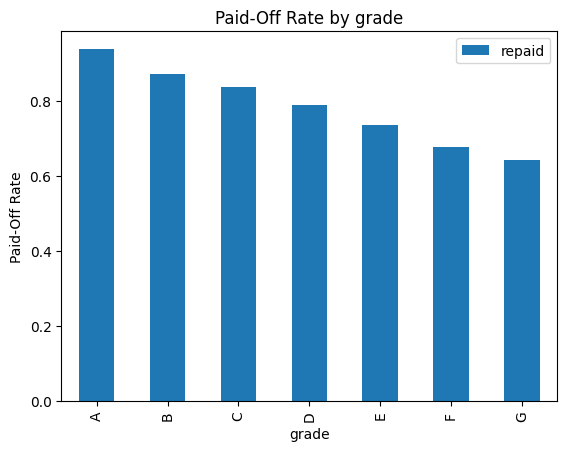

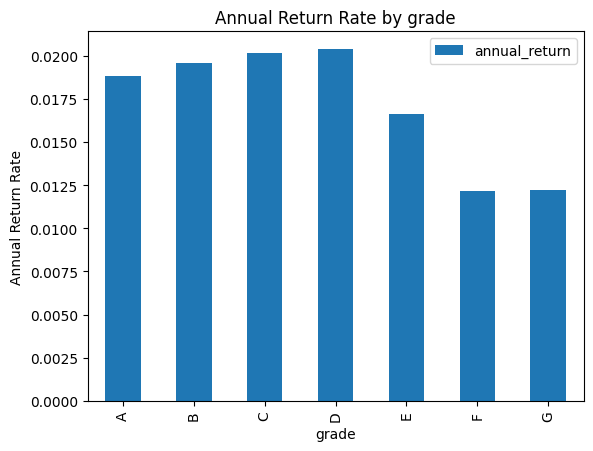

-----
Data for home_ownership
Unique values:  ['RENT' 'OWN' 'MORTGAGE' 'OTHER' 'NONE']
Total values:  home_ownership
RENT        10966
MORTGAGE     7351
OWN          1546
OTHER          44
NONE            1
Name: count, dtype: int64


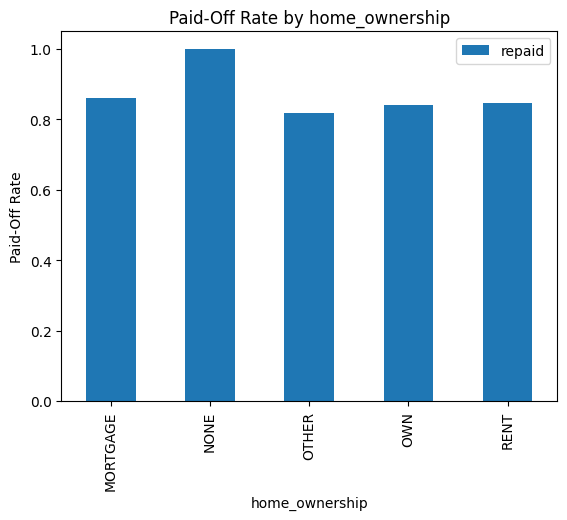

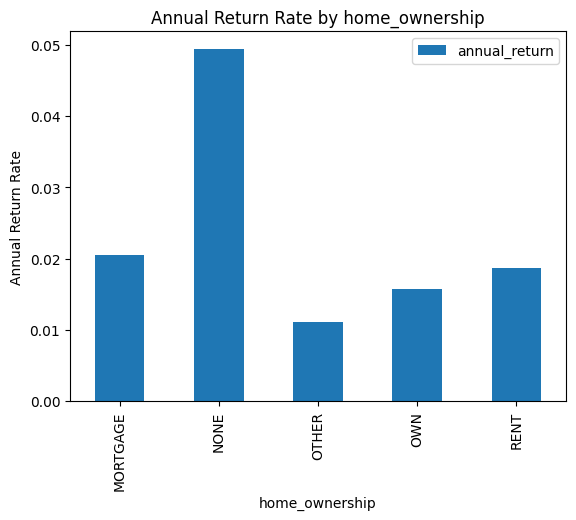

-----
Data for loan_term_year
Unique values:  [3 5]
Total values:  loan_term_year
3    14852
5     5056
Name: count, dtype: int64


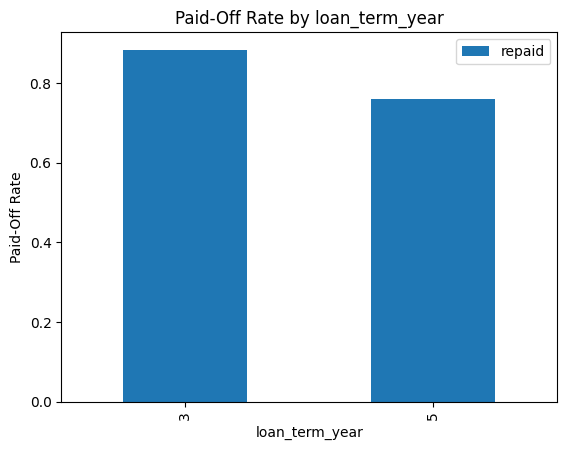

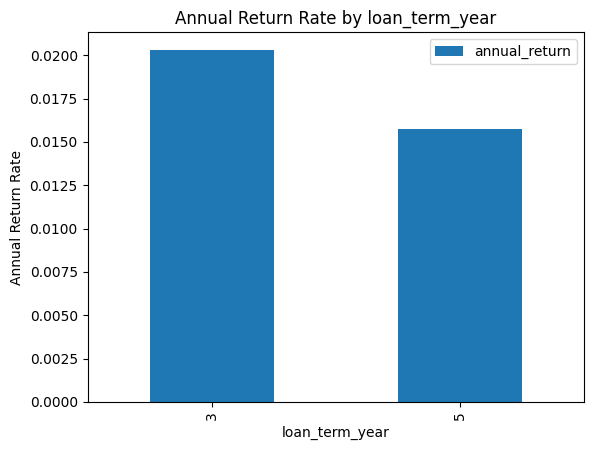

-----
Data for purpose
Unique values:  ['small_business' 'other' 'car' 'debt_consolidation' 'credit_card'
 'home_improvement' 'major_purchase' 'moving' 'medical' 'house' 'vacation'
 'wedding' 'renewable_energy' 'educational']
Total values:  purpose
debt_consolidation    9389
credit_card           2696
other                 2060
home_improvement      1330
major_purchase        1048
small_business         905
car                    687
wedding                539
medical                350
moving                 317
vacation               199
house                  176
educational            161
renewable_energy        51
Name: count, dtype: int64


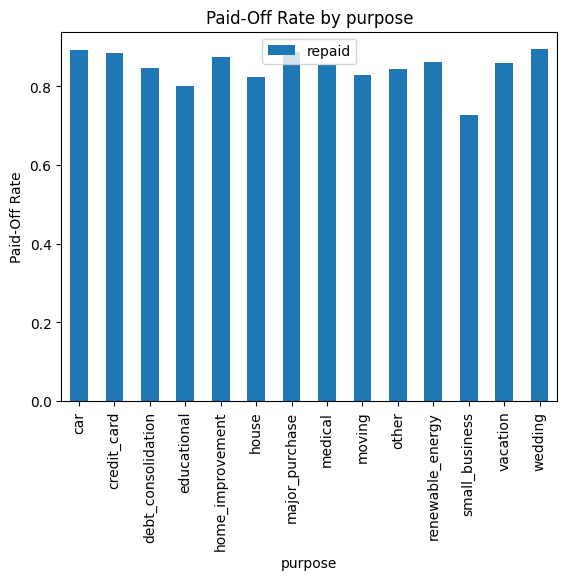

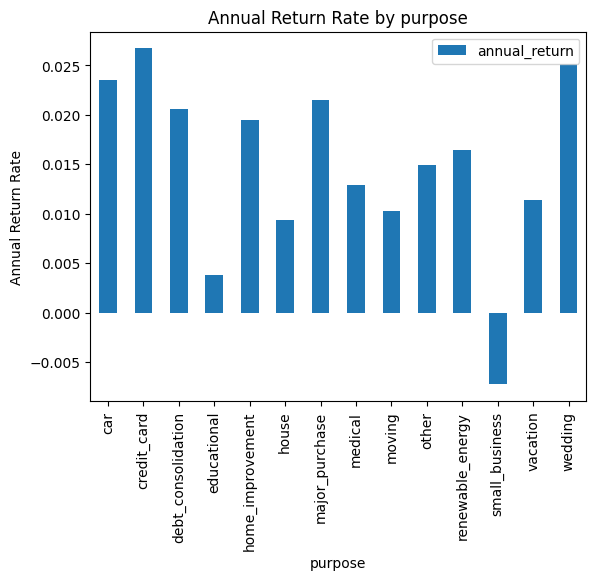

-----


In [47]:
for column in categorical_features:
    print_column_text(column)
    print("Unique values: ", loan_df[column].unique())
    print("Total values: ", loan_df[column].value_counts().sort_values(ascending=False))
    get_bar_chart(column, {"repaid": "mean"}, "Paid-Off Rate")
    get_bar_chart(column, {"annual_return": "mean"}, "Annual Return Rate")
    print("-----")


### Continuous Features - EDA


In [48]:
continuous_features.info()
continuous_features.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19908 entries, 0 to 19907
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   annual_inc             19908 non-null  float64
 1   dti                    19908 non-null  float64
 2   delinq_2yrs            19908 non-null  float64
 3   earliest_cr_line_year  19908 non-null  object 
 4   inq_last_6mths         19908 non-null  float64
 5   int_rate               19908 non-null  float64
 6   loan_amnt              19908 non-null  int64  
 7   open_acc               19908 non-null  float64
 8   revol_bal              19908 non-null  int64  
 9   revol_util             19908 non-null  float64
 10  total_acc              19908 non-null  float64
 11  total_return           19908 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 1.8+ MB


,annual_inc,dti,delinq_2yrs,inq_last_6mths,int_rate,loan_amnt,open_acc,revol_bal,revol_util,total_acc,total_return
count,1.990800e+04,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000,19908.000000
mean,7.107345e+04,13.008619,0.143962,0.829466,12.089717,11353.846444,9.278782,13363.994826,49.424966,21.527627,0.107970
std,6.980565e+04,6.663658,0.489576,1.044978,3.698287,7463.700492,4.414903,15943.303849,28.184935,11.269006,0.267606
min,4.000000e+03,0.000000,0.000000,0.000000,5.420000,500.000000,2.000000,0.000000,0.000000,2.000000,-1.000000
25%,4.200000e+04,7.840000,0.000000,0.000000,9.450000,5750.000000,6.000000,3770.500000,26.500000,13.000000,0.085900
50%,6.000000e+04,13.075000,0.000000,0.000000,11.860000,10000.000000,9.000000,8876.500000,50.200000,20.000000,0.155383
75%,8.500000e+04,18.200000,0.000000,1.000000,14.610000,15000.000000,12.000000,16952.250000,72.800000,28.000000,0.224674
max,6.000000e+06,29.990000,11.000000,8.000000,24.400000,35000.000000,44.000000,148829.000000,99.900000,90.000000,1.241516


Data for annual_inc


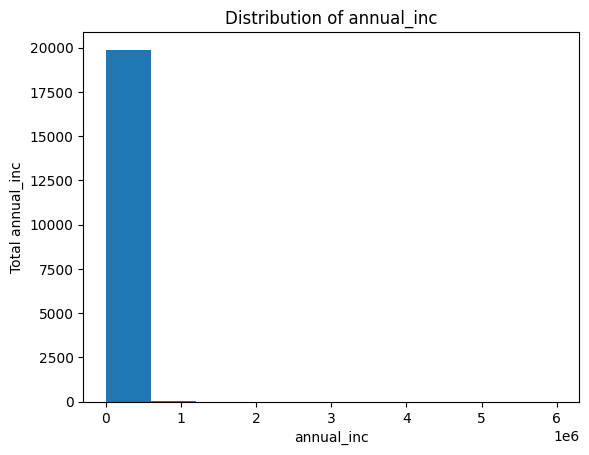

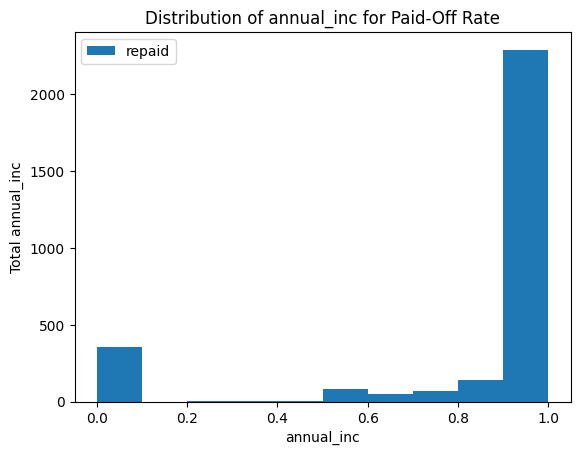

-----
Data for dti


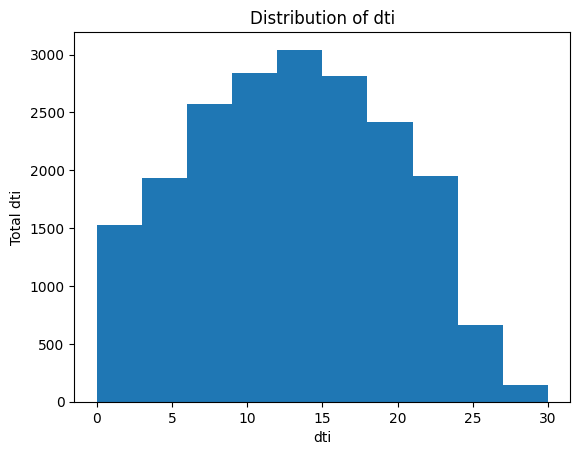

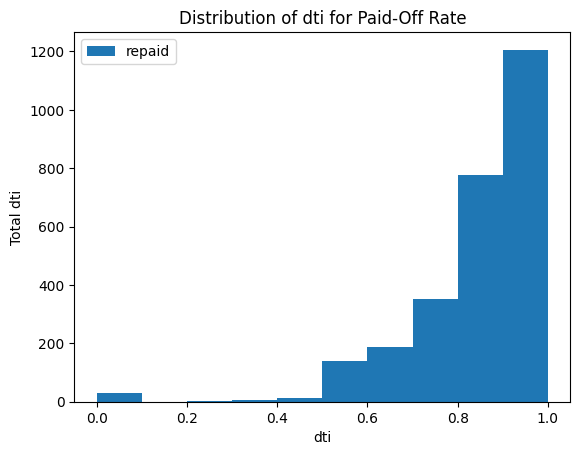

-----
Data for delinq_2yrs


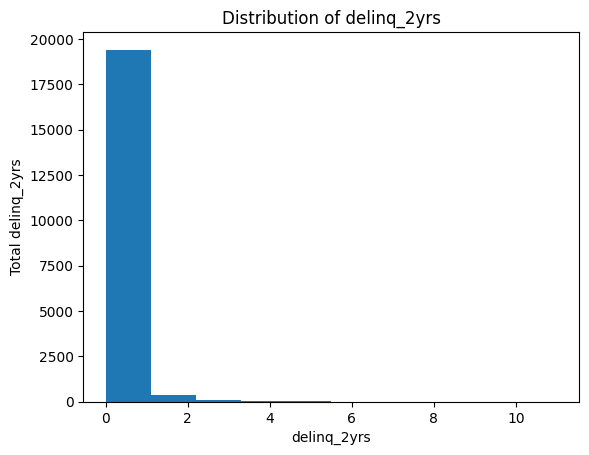

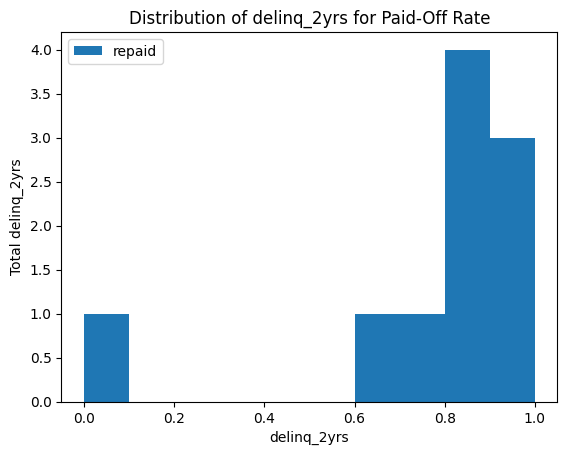

-----
Data for earliest_cr_line_year


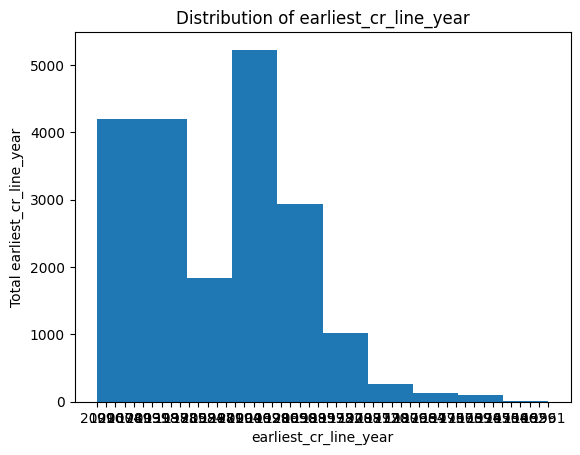

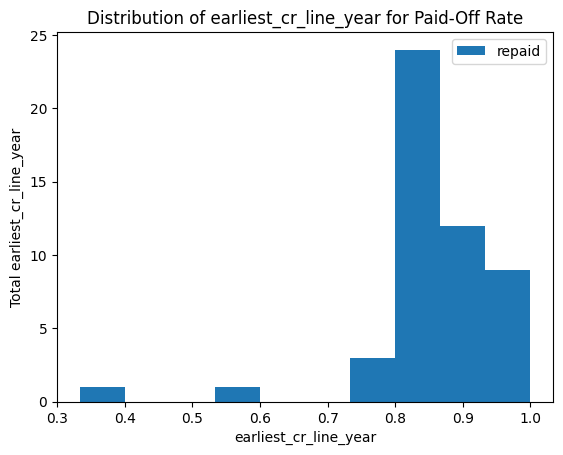

-----
Data for inq_last_6mths


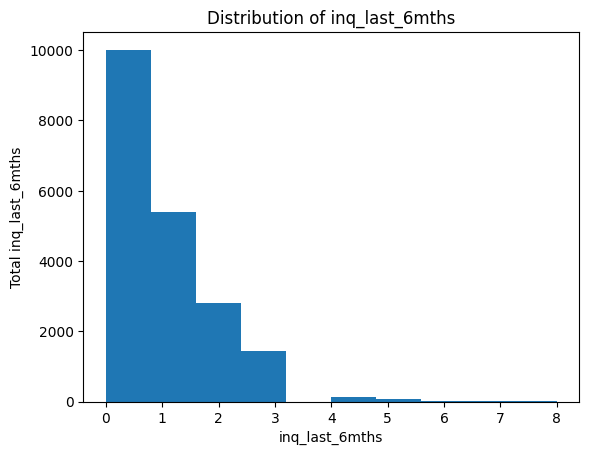

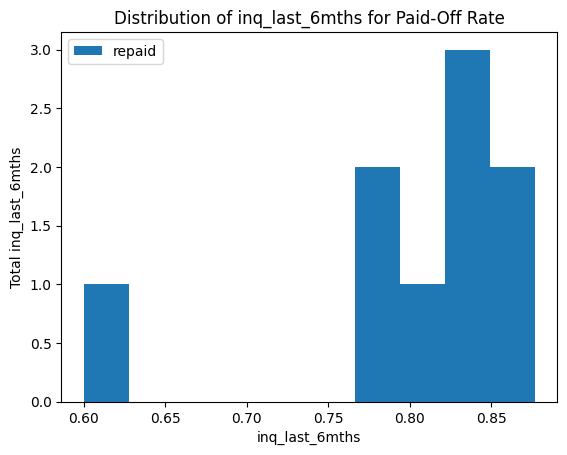

-----
Data for int_rate


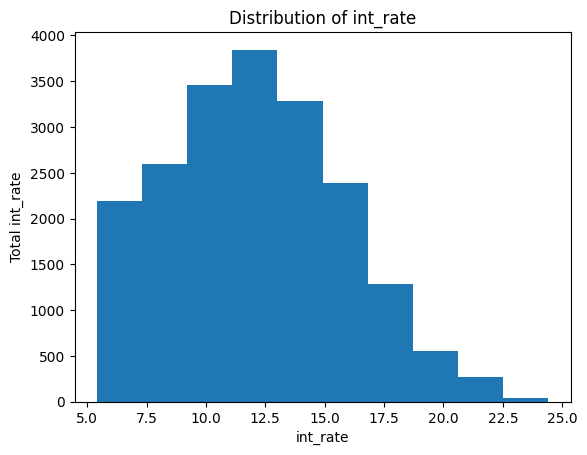

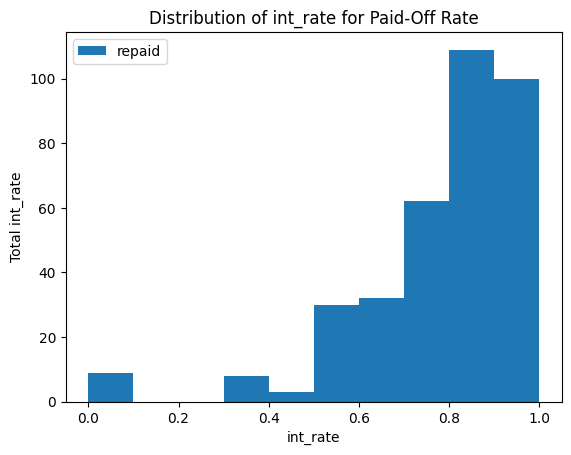

-----
Data for loan_amnt


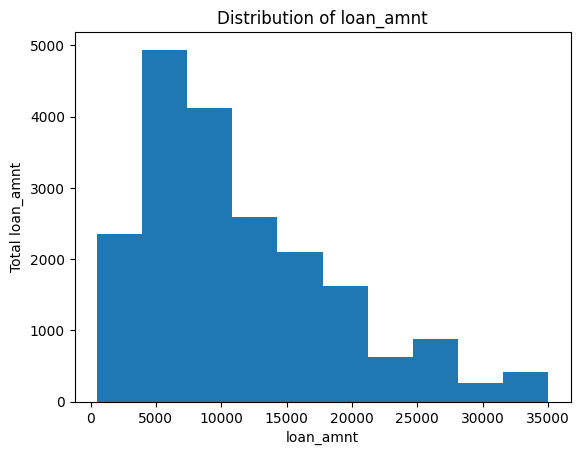

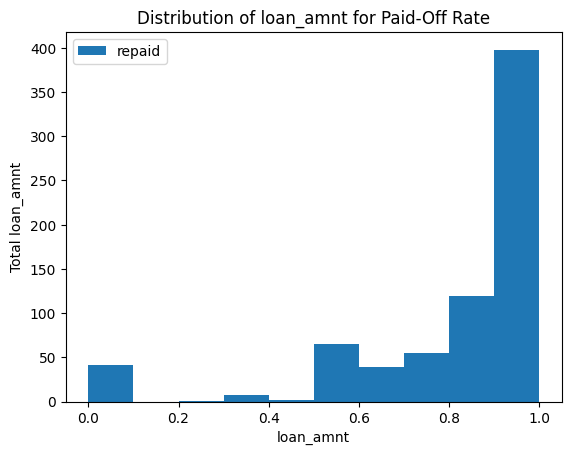

-----
Data for open_acc


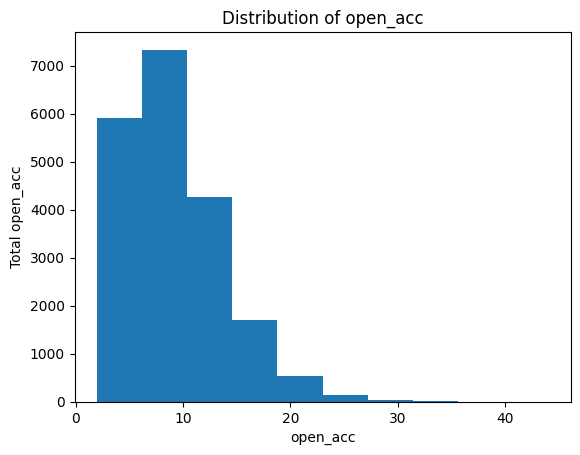

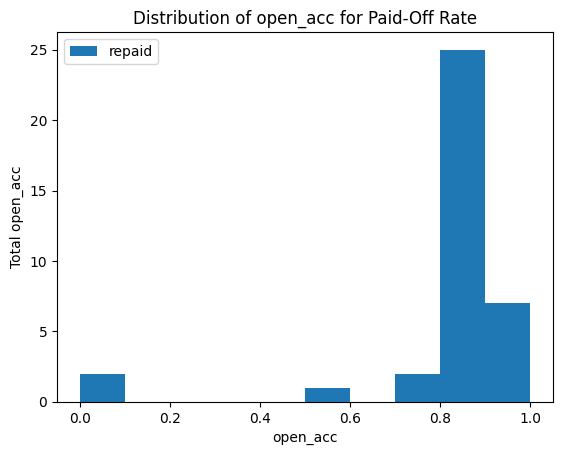

-----
Data for revol_bal


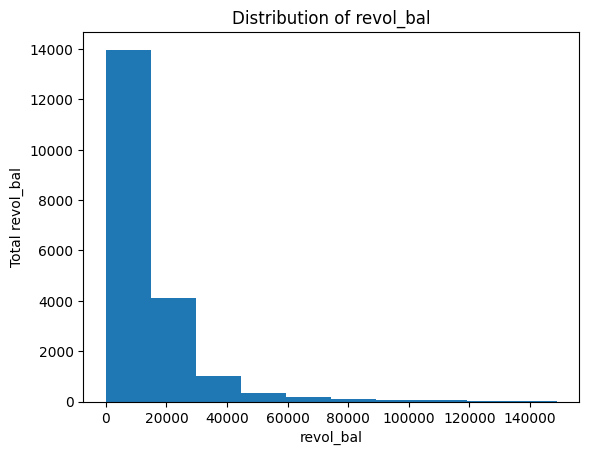

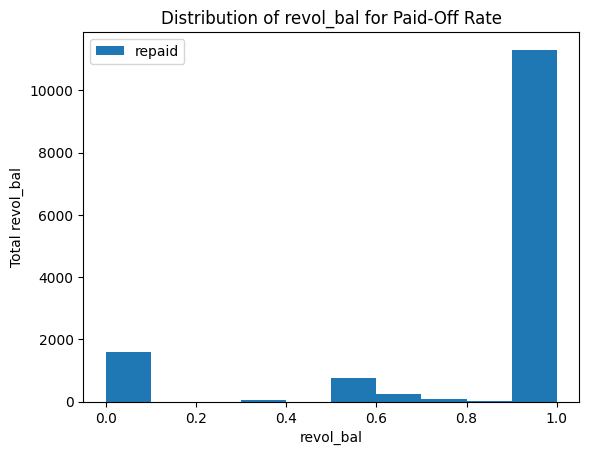

-----
Data for revol_util


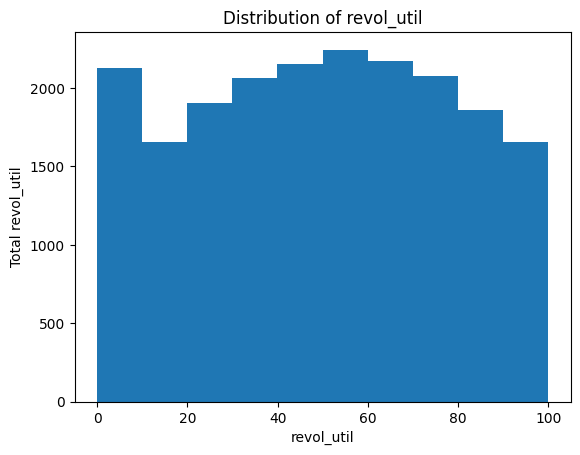

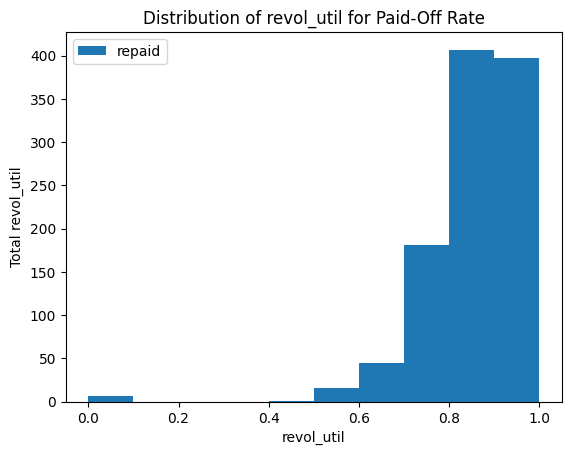

-----
Data for total_acc


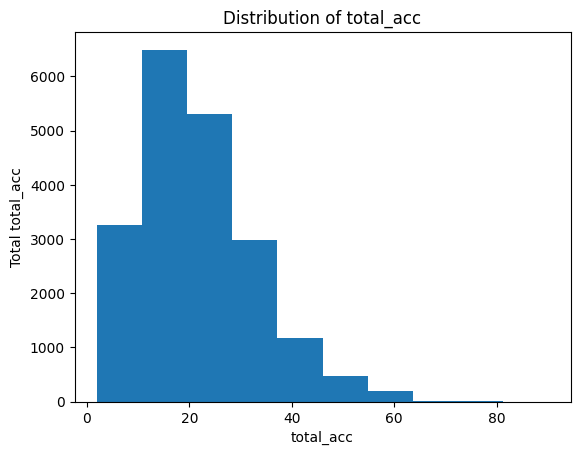

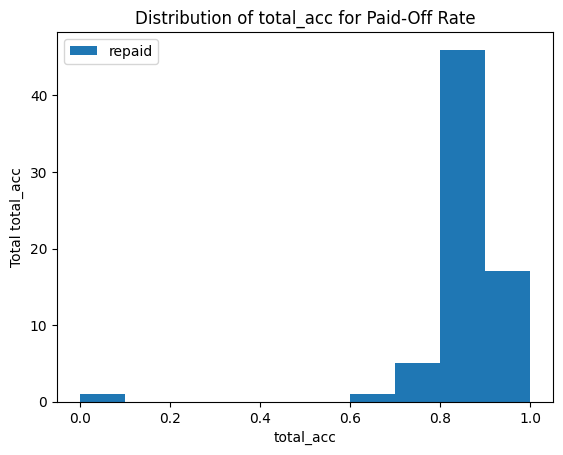

-----
Data for total_return


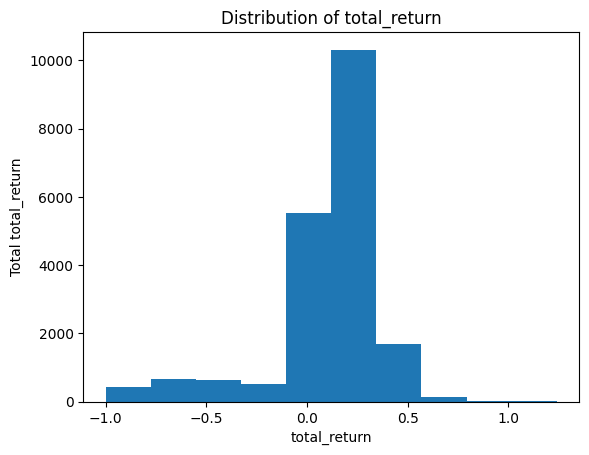

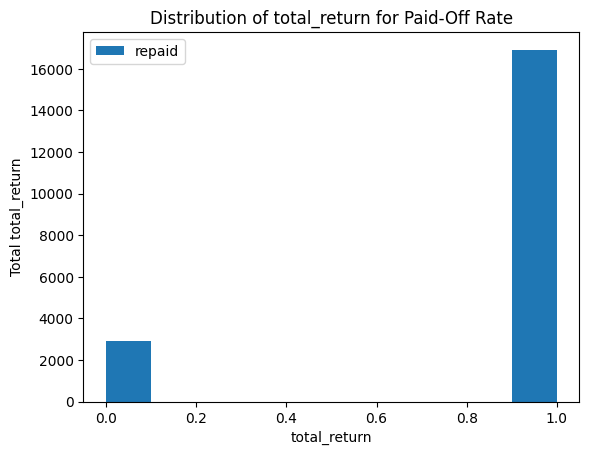

-----


In [49]:
for column in continuous_features:
    print_column_text(column)
    get_histogram(column)
    get_histogram_aggregate(column, {"repaid": "mean"}, "Paid-Off Rate")
    print("-----")


## Preprocessing


In [50]:
repaid_label

0        1
1        1
2        1
3        0
4        0
        ..
19903    1
19904    1
19905    1
19906    1
19907    1
Name: repaid, Length: 19908, dtype: int64

In [51]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    loan_features, repaid_label, test_size=0.4, random_state=23
)